# Coding Exercise: Air Quality Forecasting with SimpleRNN and LSTM


Each TODO asks for a **complete code line**, not just one missing value. Replace each `__________` with the correct line of code.

The goal is to use previous air-quality sensor measurements to predict the next value of **CO(GT)**.

Also, there are hints about the syntax of the commands, right before each of the placeholders.
Good luck!

## 1. Install and import libraries

In [ ]:
!pip -q install ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load the UCI Air Quality dataset



In [ ]:
air_quality = fetch_ucirepo(id=360)
df = air_quality.data.features.copy()

print("Original shape:", df.shape)
df.head()

Original shape: (9357, 15)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


## 3. Clean missing values

In this dataset, missing sensor values are encoded as **-200**

We replace them with `NaN`, then interpolate missing values linearly

In [ ]:
# TODO 1:
# Replace all -200 values with np.nan
# Syntax: df.replace(to_replace, value)
# Arguments:
#   to_replace = the value that should be replaced
#   value      = the new value that should be inserted instead
df = df.replace(-200, np.nan)

# Interpolate missing values and drop remaining empty rows
df = df.interpolate(method="linear").dropna()

print("Shape after cleaning:", df.shape)
df.head()

Shape after cleaning: (9357, 15)


/tmp/ipykernel_1349/2650961054.py:10: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method="linear").dropna()


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


## 4. Keep numeric columns and choose the target

We will predict CO(GT) from the previous 24 hours of measurements

Numeric columns:
['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
Target column: CO(GT)
Target index: 0


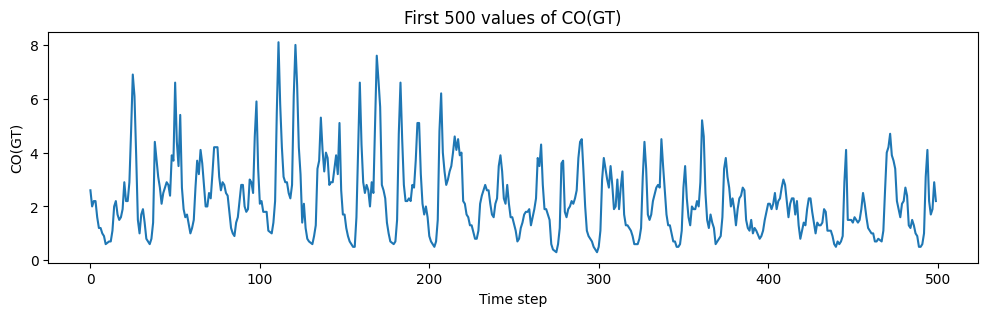

In [ ]:
# Keep only numeric columns.
numeric_df = df.select_dtypes(include=[np.number]).copy()

# Choose the target column.
target_column = "CO(GT)"
target_index = numeric_df.columns.get_loc(target_column)

print("Numeric columns:")
print(list(numeric_df.columns))
print("Target column:", target_column)
print("Target index:", target_index)

plt.figure(figsize=(12, 3))
plt.plot(numeric_df[target_column].values[:500])
plt.title("First 500 values of CO(GT)")
plt.xlabel("Time step")
plt.ylabel("CO(GT)")
plt.show()

## 5. Convert the dataframe to NumPy

Keras time-series utilities expect NumPy arrays.

In [6]:
# TODO 2:
# Convert numeric_df to a NumPy array with dtype float32 and store it in raw_data
# Syntax: dataframe.to_numpy(dtype=...)
# Arguments:
#   dtype = the data type of the output NumPy array, for example "float32"
raw_data = numeric_df.to_numpy(dtype="float32")

print("raw_data shape:", raw_data.shape)

raw_data shape: (9357, 13)


## 6. Split into train, validation, and test parts

We use the first 50% for training, the next 25% for validation, and the last 25% for testing.

For time-series data, we do not randomly shuffle before splitting. The order matters.

In [7]:
num_train_samples = int(0.50 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples

print("Train samples:", num_train_samples)
print("Validation samples:", num_val_samples)
print("Test samples:", num_test_samples)

Train samples: 4678
Validation samples: 2339
Test samples: 2340


## 7. Normalize using only the training data

Important: the mean and standard deviation must be computed only from the training part.

This avoids leaking information from validation/test data into training.

In [ ]:
# TODO 3:
# Compute the mean of the training part of raw_data along axis 0
# Syntax: array[start:end].mean(axis=...)
# Arguments:
#   start:end = the part of the array used for training
#   axis=0    = compute one mean value per feature/column
mean = raw_data[:num_train_samples].mean(axis=0)

# TODO 4:
# Compute the standard deviation of the training part of raw_data along axis 0
# Syntax: array[start:end].std(axis=...)
# Arguments:
#   start:end = the part of the array used for training
#   axis=0    = compute one standard deviation value per feature/column
std = raw_data[:num_train_samples].std(axis=0)

# Avoid division by zero if a column is constant.
std[std == 0] = 1.0

raw_data_normalized = (raw_data - mean) / std

print("Mean shape:", mean.shape)
print("Std shape:", std.shape)
print("Normalized data shape:", raw_data_normalized.shape)

## 8. Create time-series datasets

The model will see the previous **24 hours** and predict the next value of `CO(GT)`.

In [10]:
# Re-calculating raw_data_normalized as a workaround for NameError,
# as the previous cell (d963f35f) might not have been executed.
# It is recommended to run cell d963f35f before this cell.
mean = raw_data[:num_train_samples].mean(axis=0)
std = raw_data[:num_train_samples].std(axis=0)
std[std == 0] = 1.0
raw_data_normalized = (raw_data - mean) / std

# Longer context makes the task more suitable for an LSTM.
# The model sees the previous 48 hours and predicts the next CO(GT) value.
sequence_length = 48
sampling_rate = 1
batch_size = 64

# Input data contains all normalized features.
# Targets are shifted by one timestep, so every input window predicts the next hour.
data = raw_data_normalized[:-1]
targets = raw_data_normalized[1:, target_index]

train_dataset = keras.utils.timeseries_dataset_from_array(
    data=data[:num_train_samples],
    targets=targets[:num_train_samples],
    sequence_length=sequence_length,
    sampling_rate=sampling_rate,
    batch_size=batch_size,
    shuffle=True,
    seed=42,
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    data=data[num_train_samples:num_train_samples + num_val_samples],
    targets=targets[num_train_samples:num_train_samples + num_val_samples],
    sequence_length=sequence_length,
    sampling_rate=sampling_rate,
    batch_size=batch_size,
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    data=data[num_train_samples + num_val_samples:],
    targets=targets[num_train_samples + num_val_samples:],
    sequence_length=sequence_length,
    sampling_rate=sampling_rate,
    batch_size=batch_size,
)

for samples, targets_batch in train_dataset.take(1):
    print("Input sequence shape:", samples.shape)
    print("Target shape:", targets_batch.shape)

Input sequence shape: (64, 48, 13)
Target shape: (64,)


## 9. Demonstrate `return_sequences`

An RNN internally produces an output at every timestep.

Keras can return:

- only the last output: `return_sequences=False`
- the full sequence of outputs: `return_sequences=True`

In [11]:
example_batch, example_targets = next(iter(train_dataset))

# TODO 5:
# Create a SimpleRNN layer with 8 units that returns only the last output.
# Syntax: layers.SimpleRNN(units, return_sequences=...)
# Arguments:
#   units            = number of values in the hidden state/output vector
#   return_sequences = False means return only the final output
rnn_last = layers.SimpleRNN(8, return_sequences=False)

# TODO 6:
# Create a SimpleRNN layer with 8 units that returns the full output sequence.
# Syntax: layers.SimpleRNN(units, return_sequences=...)
# Arguments:
#   units            = number of values in the hidden state/output vector
#   return_sequences = True means return an output for every timestep
rnn_all = layers.SimpleRNN(8, return_sequences=True)

y_last = rnn_last(example_batch)
y_all = rnn_all(example_batch)

print("Input batch shape:", example_batch.shape)
print("return_sequences=False output shape:", y_last.shape)
print("return_sequences=True output shape:", y_all.shape)

Input batch shape: (64, 48, 13)
return_sequences=False output shape: (64, 8)
return_sequences=True output shape: (64, 48, 8)


## 10. Train a SimpleRNN model

This model returns one prediction for the whole 24-hour input sequence

Because we need one final prediction, `return_sequences=False` is enough here

In [12]:
inputs = keras.Input(shape=(sequence_length, raw_data_normalized.shape[-1]))

# TODO 7:
# Add a SimpleRNN layer with 16 units.
# Syntax: x = layers.SimpleRNN(units)(inputs)
# Arguments:
#   units  = number of values in the hidden state/output vector
#   inputs = the input sequence tensor
x = layers.SimpleRNN(16)(inputs)

simple_rnn_outputs = layers.Dense(1)(x)
simple_rnn_model = keras.Model(inputs, simple_rnn_outputs)

simple_rnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"],
)
simple_rnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 13)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# If you have time, you can inclrease the number of epochs, but it will take some time

simple_rnn_history = simple_rnn_model.fit(
    train_dataset,
    epochs=15,
    validation_data=val_dataset,
    verbose=1,
)

Epoch 1/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.6278 - mae: 0.6046 - val_loss: 2.6483 - val_mae: 1.2036
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.6202 - mae: 0.6003 - val_loss: 2.6835 - val_mae: 1.2178
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.6133 - mae: 0.5980 - val_loss: 2.7437 - val_mae: 1.2250
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.6123 - mae: 0.5963 - val_loss: 2.7054 - val_mae: 1.2168
Epoch 5/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.6061 - mae: 0.5917 - val_loss: 2.7628 - val_mae: 1.2311
Epoch 6/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.6027 - mae: 0.5911 - val_loss: 2.7579 - val_mae: 1.2297
Epoch 7/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.5995 - mae: 0.5895 - val_loss: 2.7677 - val_mae: 1.2312
Epoch 8/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.5998 - mae: 0.5880 - val_loss: 2.7589 - val_mae: 1.2319
Epoch 9/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.595

In [15]:
# SimpleRNN baseline
simple_rnn_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_mae",
        patience=10,
        restore_best_weights=True,
    )
]

simple_rnn_history = simple_rnn_model.fit(
    train_dataset,
    epochs=15,
    validation_data=val_dataset,
    callbacks=simple_rnn_callbacks,
    verbose=1,
)

Epoch 1/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.6501 - mae: 0.6154 - val_loss: 2.6818 - val_mae: 1.2131
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.6383 - mae: 0.6092 - val_loss: 2.7203 - val_mae: 1.2176
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.6307 - mae: 0.6049 - val_loss: 2.7434 - val_mae: 1.2239
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.6283 - mae: 0.6039 - val_loss: 2.7740 - val_mae: 1.2313
Epoch 5/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.6397 - mae: 0.6107 - val_loss: 2.7325 - val_mae: 1.2258
Epoch 6/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.6582 - mae: 0.6187 - val_loss: 2.6005 - val_mae: 1.2005
Epoch 7/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.6289 - mae: 0.6045 - val_loss: 2.6395 - val_mae: 1.2014
Epoch 8/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.6162 - mae: 0.5983 - val_loss: 2.7015 - val_mae: 1.2159
Epoch 9/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.614

## 11. Train an LSTM model

LSTM is a stronger recurrent layer because it has a carry/memory track

In [17]:
inputs = keras.Input(shape=(sequence_length, raw_data_normalized.shape[-1]))

# TODO 8:
# Add an LSTM layer with 16 units.
# Syntax: x = layers.LSTM(units)(inputs)
# Arguments:
#   units  = number of values in the LSTM output vector
#   inputs = the input sequence tensor
x = layers.LSTM(16)(inputs)

# TODO 9:
# Add a Dense output layer with 1 unit.
# Syntax: outputs = layers.Dense(units)(x)
# Arguments:
#   units = number of values to predict; use 1 for one regression value
#   x     = the output of the previous layer
outputs = layers.Dense(1)(x)

lstm_model = keras.Model(inputs, outputs)

# TODO 10:
# Compile the LSTM model using optimizer="rmsprop", loss="mse", and metrics=["mae"].
# Syntax: model.compile(optimizer=..., loss=..., metrics=...)
# Arguments:
#   optimizer = algorithm used to update the weights
#   loss      = function the model minimizes during training
#   metrics   = extra values shown during training/evaluation
lstm_model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

lstm_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 13)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16)             │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,937 (7.57 KB)

 Trainable params: 1,937 (7.57 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Advanced model training.
# EarlyStopping keeps the best validation model instead of the last epoch.
# ReduceLROnPlateau lowers the learning rate when validation MAE stops improving.
lstm_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_mae",
        patience=6,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_mae",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
    ),
]

lstm_history = lstm_model.fit(
    train_dataset,
    epochs=15,
    validation_data=val_dataset,
    callbacks=lstm_callbacks,
    verbose=1,
)

Epoch 1/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.9314 - mae: 0.7533 - val_loss: 2.4280 - val_mae: 1.1852 - learning_rate: 0.0010
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.8402 - mae: 0.7107 - val_loss: 2.4436 - val_mae: 1.1731 - learning_rate: 0.0010
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.7552 - mae: 0.6612 - val_loss: 2.4055 - val_mae: 1.1570 - learning_rate: 0.0010
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.6806 - mae: 0.6183 - val_loss: 2.5993 - val_mae: 1.1887 - learning_rate: 0.0010
Epoch 5/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.6285 - mae: 0.5896 - val_loss: 2.6430 - val_mae: 1.1996 - learning_rate: 0.0010
Epoch 6/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.5923 - mae: 0.5696 - val_loss: 2.6260 - val_mae: 1.1992 - learning_rate: 0.0010
Epoch 7/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.5597 - mae: 0.5517 - val_loss: 2.5142 - val_mae: 1.1760 - learning_rate: 5.0000e-04
Epoch 8/1

## 12. Compare the validation curves

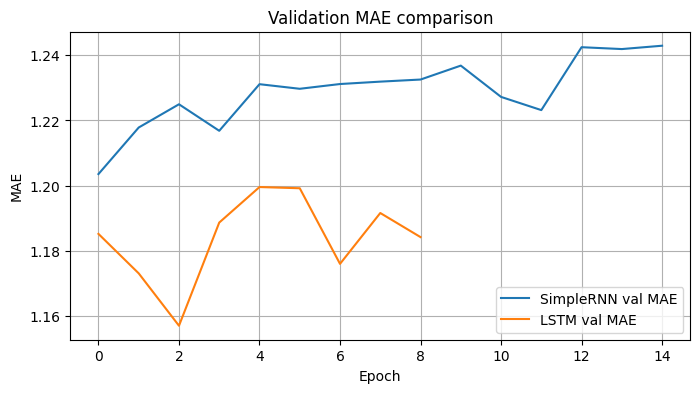

SimpleRNN test MAE: 0.8963935971260071
LSTM test MAE: 0.8812106251716614


In [19]:
plt.figure(figsize=(8, 4))
plt.plot(simple_rnn_history.history["val_mae"], label="SimpleRNN val MAE")
plt.plot(lstm_history.history["val_mae"], label="LSTM val MAE")
plt.title("Validation MAE comparison")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()

simple_rnn_test_mae = simple_rnn_model.evaluate(test_dataset, verbose=0)[1]
lstm_test_mae = lstm_model.evaluate(test_dataset, verbose=0)[1]

print("SimpleRNN test MAE:", simple_rnn_test_mae)
print("LSTM test MAE:", lstm_test_mae)

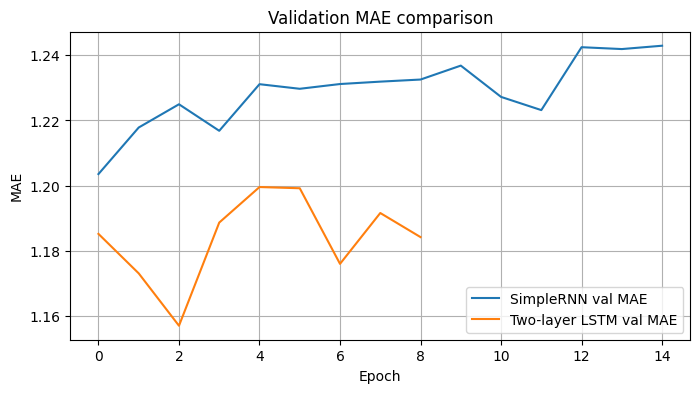

SimpleRNN results: {'loss': 1.30271315574646, 'compile_metrics': 0.8963935971260071}
Two-layer LSTM results: {'loss': 1.372183918952942, 'compile_metrics': 0.8812106251716614}

Lower MAE is better.
SimpleRNN test MAE: 0.8964
Two-layer LSTM test MAE: 0.8812
The advanced model performed better on the test set in this run.


In [20]:
plt.figure(figsize=(8, 4))
plt.plot(simple_rnn_history.history["val_mae"], label="SimpleRNN val MAE")
plt.plot(lstm_history.history["val_mae"], label="Two-layer LSTM val MAE")
plt.title("Validation MAE comparison")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()

simple_rnn_results = simple_rnn_model.evaluate(test_dataset, verbose=0)
lstm_results = lstm_model.evaluate(test_dataset, verbose=0)

simple_rnn_metrics = dict(zip(simple_rnn_model.metrics_names, simple_rnn_results))
lstm_metrics = dict(zip(lstm_model.metrics_names, lstm_results))

print("SimpleRNN results:", simple_rnn_metrics)
print("Two-layer LSTM results:", lstm_metrics)

simple_rnn_mae = simple_rnn_results[1]
lstm_mae = lstm_results[1]

print("\nLower MAE is better.")
print(f"SimpleRNN test MAE: {simple_rnn_mae:.4f}")
print(f"Two-layer LSTM test MAE: {lstm_mae:.4f}")

if lstm_mae < simple_rnn_mae:
    print("The advanced model performed better on the test set in this run.")
else:
    print("The SimpleRNN performed better on the test set in this run. Try rerunning or increasing training time.")

## Final questions

### Question 1
What does `return_sequences=True` do?

A. It returns only the last output of the RNN.  
B. It returns an output for every timestep.  
C. It removes the recurrent state.

### Question 2
Why do we compute `mean` and `std` only on the training part?

A. To avoid using information from validation/test data during preprocessing.  
B. Because validation data does not have numeric values.  
C. Because RNNs cannot use normalized data.

### Question 3
Why is LSTM usually better than SimpleRNN for longer sequences?

A. LSTM has gates and a memory/carry state that help preserve useful information.  
B. LSTM has no trainable weights.  
C. LSTM ignores the previous state.